![title](img/SupFig6.png)

# Supplementary Figure 6
(a) Backward particle trajectories with particles initialized in the equatorial thermocline in FOSI. Initial particle positions are indicated by black dots. Shading indicates the pathway density. (b) Same as (a) but for LENS. Colored lines show trajectories from the ensemble member most similar to the FOSI simulation in each hemisphere. Shading indicates the 10-member mean pathway density. (c) Pathway density difference (LENS minus FOSI) for backward particle trajectories initialized in the equatorial thermocline.

### Imports

In [1]:
import pop_tools
import xarray as xr
import numpy as np
import cftime
import xesmf as xe
import cmocean
import matplotlib.pyplot as plt
import matplotlib.collections as mcollections
import matplotlib.patches as patches
from matplotlib.patches import Polygon
import cartopy.crs as ccrs
from scipy.signal import coherence, csd
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks
from scipy.stats import linregress
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import xesmf as xe
import pop_tools
import cftime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import gaussian_kde

import warnings
warnings.filterwarnings('ignore')  # Add this at the top of your script

/glade/u/apps/opt/conda/envs/npl-2025b/lib/python3.12/site-packages/pop_tools/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
import processing_utils as proc_utils
import cesm2_lens_utils
import analysis_funcs as afuncs
import stc_funcs as stcfuncs

### Functions

In [3]:
def regrid_SMYLE(ds, glat=1, glon=1): # from Jacob's notebook
    """
    Inputs:
        ds: xr.DataArray with coordinates that include TLAT and TLONG
    Returns:
        Regridded xr.DataArray with coordinates lat and lon
    """
    ds = ds.rename(({'ULONG': 'lon', 'ULAT': 'lat'}))
    ds_out = xe.util.grid_global(glon, glat)
    regridder = xe.Regridder(ds, ds_out, 'bilinear', periodic=True)
    regridded = regridder(ds)
    new_coords = regridded.assign_coords({'y': regridded.lat[:, 0].values, 'x': regridded.lon[0].values})
    return new_coords.drop_vars(['lat', 'lon']).rename({'x': 'lon', 'y': 'lat'})

### Set up

In [4]:
# LENS for regridding purposes
CESMLENS_var = afuncs.LENS_for_regridding() # this is Area

#### FOSI set up
firstyear = 1959
lastyear = 2020
grid = pop_tools.get_grid('POP_gx1v7')
mask = xr.where((grid['REGION_MASK']>0) & (grid['REGION_MASK']<9), 1, np.nan)
fpath = '/glade/campaign/cesm/development/espwg/SMYLE/initial_conditions/SMYLE-FOSI/ocn/proc/tseries/month_1/'
fosi_montime_vals = [cftime.DatetimeNoLeap(1958+year, 1+month, 15) for year in range(63) for month in range(12)]

### Plotting

In [64]:
# LENS --- EQ THERMOCLINE
ENS_MEMBERS_LIST = [0, 65,  32, 85, 61, 90, 80, 68, 73, 49] #[0, 65,  32, 85, 61, 90, 80, 68, 73, 49] 

region_indx_list = []; da_list = []
lon_trunc_list = []; lat_trunc_list = []; z_trunc_list = []

for ENS_MEMB in ENS_MEMBERS_LIST:
    print(ENS_MEMB)
    file_path = "/glade/derecho/scratch/cassiacai/particle_trajectories/particle_trajectories_lens{}_EQ_startingat5m_1958_1977.zarr".format(
        ENS_MEMB)

    lens_pt = xr.open_zarr(file_path)
    l_time, l_lon, l_lat, l_z = stcfuncs.compute_data(lens_pt)

    ### NORTH PACIFIC
    da_l, region_idx_l,lon_trunc_l,lat_trunc_l, z_trunc_l = stcfuncs.calc_density_eqthermocline(
       lon_data=l_lon, lat_data=l_lat, z_data=l_z, 
        lat_min=-1, lat_max=1, lon_min=140, lon_max=280,
        timestart=0, timeend=244)
    
    region_indx_list.append(region_idx_l)
    lon_trunc_list.append(lon_trunc_l)
    lat_trunc_list.append(lat_trunc_l)
    z_trunc_list.append(z_trunc_l)
    da_list.append(da_l)

0
65
32
85
61
90
80
68
73
49


In [73]:
da_xr = xr.concat(da_list, dim='ensemble')

In [32]:
da_diff = da_xr - da_f
da_diff.mean(dim=('y','x')).argmin()

<xarray.DataArray 'density' ()> Size: 8B
array(0)

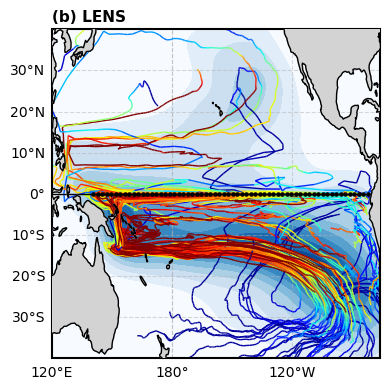

In [102]:
da = da_xr.mean(dim='ensemble')
lon_data= lon_trunc_list[0][ :, 0:244]
lat_data= lat_trunc_list[0][:, 0:244]
z_data= z_trunc_list[0][:, 0:244]
region_idx = region_indx_list[0]

fig, ax = plt.subplots(figsize=(4, 4),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -40, 40], crs=ccrs.PlateCarree())
# ax.set_extent([120, 284, -5, 50], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

ax.scatter(lon_trunc_list[0][region_idx, 0][::2], lat_trunc_list[0][region_idx, 0][::2], 
           s=5, c='k', marker='o', edgecolor='k', zorder=200,transform=ccrs.PlateCarree())

# #### CONTOURF AND CONTOUR
contourf_plot = da.plot.contourf(
    x='lon', y='lat', cmap='Blues', add_colorbar=False, transform=ccrs.PlateCarree(),
    levels=11, vmax=30e-5, vmin=0, alpha=1) # 60 for SH

#### TRAJECTORIES
for i in region_indx_list[0][::2]:
    lon = lon_trunc_list[0].isel(trajectory=i).values
    lat = lat_trunc_list[0].isel(trajectory=i).values
    depth = z_trunc_list[0].isel(trajectory=i).values
    points = np.array([lon, lat]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = mcollections.LineCollection(
            segments, cmap='jet', norm=plt.Normalize(0, 25000), 
            linewidth=1., alpha=1, transform=ccrs.PlateCarree())
    lc.set_array(depth[:-1])
    ax.add_collection(lc)

# #### COLORBAR
# density_sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(0.5e-5, 80.5e-5))
# density_sm.set_array([])
# density_cbar = plt.colorbar(density_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
# density_cbar.set_label('Normalized Trajectory Density', fontsize=11)
# tick_values = np.arange(0, 90, 20)  # This gives 5, 10, 15, 20, 25, 30
# density_cbar.set_ticks(tick_values * 1e-5)
# density_cbar.set_ticklabels([f'{x}' for x in tick_values])  # Shows as 5, 10, 15, etc.
# density_cbar.ax.tick_params(labelsize=12)

#### TITLE
plt.title('(b) LENS', fontsize=11, fontweight='bold', zorder=11, loc='left')
plt.tight_layout()
plt.show()

In [76]:
filepath = "/glade/derecho/scratch/cassiacai/particle_trajectories/particle_trajectories_fosi{}_EQ_startingat5m_1958_1977.zarr"
fosi_data_xarray = xr.open_zarr(filepath)
f_time, f_lon, f_lat, f_z = stcfuncs.compute_data(fosi_data_xarray)

da_f, region_idx_f, lon_trunc_f,lat_trunc_f, z_trunc_f = stcfuncs.calc_density_eqthermocline(
   lon_data=f_lon, lat_data=f_lat, z_data=f_z, 
    lat_min=-1, lat_max=1, 
    lon_min=140, lon_max=280, # 200, 260
    timestart=0, timeend=244)

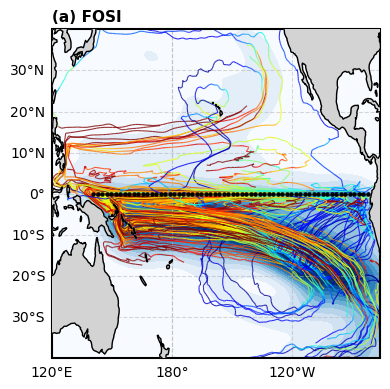

In [101]:
da = da_f
lon_data= lon_trunc_f[:, 0:244]
lat_data= lat_trunc_f[:, 0:244]
z_data= z_trunc_f[:, 0:244]
region_idx = region_idx_f

fig, ax = plt.subplots(figsize=(4, 4), #4, 3
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -40, 40], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

ax.scatter(lon_trunc_f[region_idx, 0][::2], lat_trunc_f[region_idx, 0][::2], 
           s=5, c='k', marker='o', edgecolor='k', zorder=200,transform=ccrs.PlateCarree())

# #### CONTOURF AND CONTOUR
contourf_plot = da_f.plot.contourf(
    x='lon', y='lat', cmap='Blues', add_colorbar=False, transform=ccrs.PlateCarree(),
    levels=11, vmax=30e-5, vmin=0, alpha=1)

#### TRAJECTORIES
for i in region_idx[::2]:
    lon = lon_data.isel(trajectory=i).values
    lat = lat_data.isel(trajectory=i).values
    depth = z_data.isel(trajectory=i).values
    points = np.array([lon, lat]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = mcollections.LineCollection(
            segments, cmap='jet', norm=plt.Normalize(0, 25000), 
            linewidth=0.8, alpha=0.8, transform=ccrs.PlateCarree())
    lc.set_array(depth[:-1])
    ax.add_collection(lc)

# #### COLORBAR
# density_sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(0e-5, 40e-5))
# density_sm.set_array([])
# density_cbar = plt.colorbar(density_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
# density_cbar.set_label('Normalized Trajectory Density', fontsize=11)
# tick_values = np.arange(0, 45, 5)  # This gives 5, 10, 15, 20, 25, 30
# density_cbar.set_ticks(tick_values * 1e-5)
# density_cbar.set_ticklabels([f'{x}' for x in tick_values])  # Shows as 5, 10, 15, etc.
# density_cbar.ax.tick_params(labelsize=12)

plt.title('(a) FOSI', fontsize=11, fontweight='bold', zorder=11, loc='left')
plt.tight_layout()
plt.show()

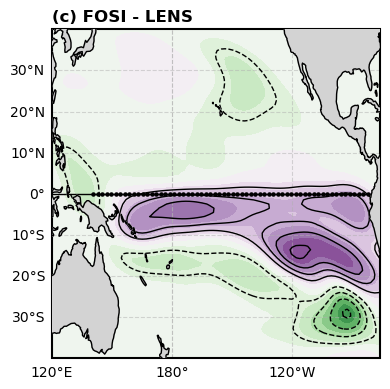

In [88]:
da_diff = da_f - da_l

fig, ax = plt.subplots(figsize=(4, 4),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -40, 40], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)

ax.scatter(lon_trunc_f[region_idx, 0][::2], lat_trunc_f[region_idx, 0][::2], 
           s=5, c='k', marker='o', edgecolor='k', zorder=200,transform=ccrs.PlateCarree())

# #### CONTOURF AND CONTOUR
contourf_plot = da_diff.plot.contourf(
    x='lon', y='lat', cmap='PRGn_r', add_colorbar=False, transform=ccrs.PlateCarree(),
    alpha=1, vmin=-30e-5, vmax=30e-5, levels=21)

da_diff.plot.contour(
    x='lon', y='lat', transform=ccrs.PlateCarree(), colors='k', linewidths=1,
    levels=[-20e-5, -15e-5, -10e-5, -5e-5, 5e-5, 10e-5, 15e-5, 20e-5], alpha=1)

# #### COLORBAR
# density_sm = plt.cm.ScalarMappable(cmap='PRGn', norm=plt.Normalize(-30e-5, 30e-5))
# density_sm.set_array([])
# density_cbar = plt.colorbar(density_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
# density_cbar.set_label('Normalized Trajectory Density', fontsize=11)
# tick_values = np.arange(-30, 35, 10)  # This gives 5, 10, 15, 20, 25, 30
# density_cbar.set_ticks(tick_values * 1e-5)
# density_cbar.set_ticklabels([f'{x}' for x in tick_values])  # Shows as 5, 10, 15, etc.
# density_cbar.ax.tick_params(labelsize=12)

plt.title('(c) FOSI - LENS', fontsize=12, fontweight='bold', zorder=11, loc='left')
plt.tight_layout()
plt.show()

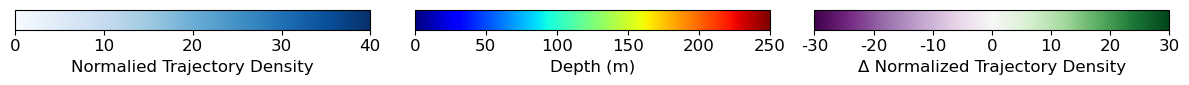

In [149]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 0.95))

# Blues colorbar
density_sm1 = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(0, 40e-5))
cbar1 = plt.colorbar(density_sm1, cax=ax1, orientation='horizontal')
cbar1.set_label('Normalied Trajectory Density', fontsize=12)
tick_values1 = np.arange(0, 45, 10)  # 0, 0.5, 1.0, 1.5, 2.0
cbar1.set_ticks(tick_values1 * 1e-5)
cbar1.set_ticklabels([f'{x:.0f}' for x in tick_values1])
cbar1.ax.tick_params(labelsize=12)

# Balance colorbar  
density_sm2 = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(0, 250))
cbar2 = plt.colorbar(density_sm2, cax=ax2, orientation='horizontal')
cbar2.set_label('Depth (m)', fontsize=12)
tick_values2 = np.arange(0, 260, 50)  # -0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3
cbar2.set_ticks(tick_values2 * 1)
cbar2.set_ticklabels([f'{x:.0f}' for x in tick_values2])
cbar2.ax.tick_params(labelsize=12)

# Balance colorbar  
density_sm2 = plt.cm.ScalarMappable(cmap='PRGn', norm=plt.Normalize(-30e-5, 30e-5))
cbar2 = plt.colorbar(density_sm2, cax=ax3, orientation='horizontal')
cbar2.set_label('Δ Normalized Trajectory Density', fontsize=12)
tick_values2 = np.arange(-30, 35, 10)  # -0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3
cbar2.set_ticks(tick_values2 * 1e-5)
cbar2.set_ticklabels([f'{x:.0f}' for x in tick_values2])
cbar2.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()